# 파서학개론

## PDF란?

### **PDF 기본 요소**
**PDF의 가장 기본 요소 = 객체**

두 종류의 객체가 존재함.
1. 직접 객체
2. 간접 객체

**1. 직접 객체**
```
true false                       % Boolean
123 -98 34.5                     % Number
(Hello)                          % Literal string
<48656C6C6F>                     % Hexadecimal string
/Type /Catalog                   % Name object
[0 0 612 792]                    % Array
<< /Type /Page /Parent 2 0 R >>  % Dictionary
stream ... endstream             % Stream object
null                             % Null object
```

**2. 간접 객체**
```
12 0 obj ... endobj              % 간접 객체 선언
12 0 R                           % 간접 객체 호출
```

*\+ 간접 객체 식별 방법*
```
<object number> <generation number> ...
```

---

### **파일 구조**

#### **PDF = Header + Body + Cross-reference table + Trailer**

Header : 파일의 첫 줄. PDF 규격의 버전을 식별함.

Body : 간접 객체들 + 문서 요소 표현 + 객체 스트림

Cross-reference table : 간접 객체들이 파일의 어느 위치에 있는지(바이트 오프셋)에 대한 정보를 담고 있는 테이블.

Trailer : PDF 리더기가 문서의 구조를 파악하기 위해 가장 먼저 참고하는 영역.

---

#### PDF는 뒤에서 앞으로 해석!!!

---

### **[1] Header**
시작이 되는 부분

예시
```
%PDF-1.7
%도도
```

`%`는 PDF에서 주석을 의미. 
첫 번째 주석은 PDf 버전을 의미
두 번째 주석은 해당 파일이 바이너리 파일이라는 의미 (128 이상의 바이트를 최소 4개 이상 넣음)

### **[2] Trailer**

**Trailer 역할**
1. Cross-reference table의 위치 제공
2. Body의 특정 특수 객체들의 위치 제공
3. 파일의 끝을 알리는 %%EOF 마커
4. 상호 참조 테이블이 시작되는 바이트 오프셋 위치(startxref)
5. 문서 계층 구조의 최상위 객체인 카탈로그 딕셔너리(Root) 정보

**Trailer 예시**
```
trailer
<<
    /Size 117
    /Root 1 0 R
    /Info 14 0 R
    /ID[
        <9B8EA23639C1DA4FA67B9B17AEFF023D>
        <9B8EA23639C1DA4FA67B9B17AEFF023D>
    ] 
>>
startxref
27593
%%EOF
```

Trailer는 PDF 파일을 수정하면 추가될 수 있다. 그런 경우 추가된 객체와 /Prev 와 /XReStm 등으로 추가 정보를 표현한다.

예시
```
trailer
<<
    /Size 117
    /Root 1 0 R
    /Info 14 0 R
    /ID[
        <9B8EA23639C1DA4FA67B9B17AEFF023D>
        <9B8EA23639C1DA4FA67B9B17AEFF023D>
    ] 
>>
startxref
27593
%%EOF

xref
0 0
trailer
<<
/Size 117
/Root 1 0 R
/Info 14 0 R
/ID[
    <9B8EA23639C1DA4FA67B9B17AEFF023D>
    <9B8EA23639C1DA4FA67B9B17AEFF023D>
] 
/Prev 27593
/XRefStm 27121
>>
startxref
30092
%%EOF
```

---

### **[3] Cross-reference table**

줄여서 xref 라고 PDF에 표기함.

trailer에 존재하는 startxref가 xref의 위치를 알려줌.

xref 태그부터 trailer 태그 전까지가 모두 Cross-reference table 영역.

예시
```
xref
0 6
0000000003 65535 f
0000000017 00000 n
0000000081 00000 n
0000000000 00007 f
0000000331 00000 n
0000000409 00000 n
```

의미 해석

```
xref = cross-reference table 시작
0 6 = 0부터 시작하는 객체가 6개 있다.
0000000003 65535 f = 0번 객체
0000000017 00000 n = 1번 객체
0000000081 00000 n = 2번 객체
0000000000 00007 f = 3번 객체
0000000331 00000 n = 4번 객체
0000000409 00000 n = 5번 객체
```

**객체 사용 여부**
```
n = in-use (사용 중) | f = free (사용 안함)
```



**앞의 두 숫자의 의미**
1. n인 경우
```
0000000017 00000 n

<byte offset> <generation> n
```

해석 >> 17 바이트 위치에 해당 객체가 시작되고, 이 객체의 세대(버전)는 0번 이고, 사용되고 있는 객체이다.

2. f인 경우
```
0000000003 65535 f

<next free obj num> <generation> f
```
해석 >> 다음 free 객체의 번호는 3 이고, 더 이상 재사용 금지! (65535는 PDF generation number의 최대값)

---

#### **(실습) PDF에서 Trailer와 Cross-reference table 확인해보기**

In [1]:
# PDF 선택
# - 같은 폴더에 "파서학개론.pdf"가 있으면 해당 파일을 사용합니다.
# - 없으면 현재 폴더의 첫 번째 PDF 파일을 사용합니다.
from pathlib import Path

pdf_path = Path("파서학개론.pdf")

if not pdf_path.exists():
    pdf_candidates = sorted(Path(".").glob("*.pdf"))
    if pdf_candidates:
        pdf_path = pdf_candidates[0]
    else:
        raise FileNotFoundError("현재 폴더에서 PDF 파일을 찾지 못했습니다. 실습용 PDF를 노트북과 같은 폴더에 넣어 주세요.")

print(f"사용할 PDF: {pdf_path}")


사용할 PDF: 파서학개론.pdf


In [2]:
# PDF를 byte로 읽기
raw_pdf = None

with open(pdf_path, "rb") as f:
    raw_pdf = f.read()

In [3]:
# header 100 바이트만 출력
print(raw_pdf[:100])

b'%PDF-1.7\r\n%\xb5\xb5\xb5\xb5\r\n1 0 obj\r\n<</Type/Catalog/Pages 2 0 R/Lang(ko-KR) /StructTreeRoot 15 0 R/MarkInfo<</'


In [4]:
# tail 100 바이트만 출력
print(raw_pdf[-100:])

b'B17AEFF023D><9B8EA23639C1DA4FA67B9B17AEFF023D>] /Prev 27593/XRefStm 27121>>\r\nstartxref\r\n30092\r\n%%EOF'


In [5]:
# 예쁘게 보기 위해서 latin-1 디코딩 적용
print(raw_pdf[:100].decode('latin-1'))

%PDF-1.7
%µµµµ
1 0 obj
<</Type/Catalog/Pages 2 0 R/Lang(ko-KR) /StructTreeRoot 15 0 R/MarkInfo<</


In [6]:
print(raw_pdf[-100:].decode('latin-1'))

B17AEFF023D><9B8EA23639C1DA4FA67B9B17AEFF023D>] /Prev 27593/XRefStm 27121>>
startxref
30092
%%EOF


In [7]:
# trailer의 구성요소 중 하나인 %%EOF 확인 가능
print(raw_pdf[-5:].decode("latin-1"))

%%EOF


In [8]:
# startxref가 가리키는 byte offset에서 끝까지(xref + trailer) 출력
import re

m = list(re.finditer(rb"startxref\s+(\d+)\s+%%EOF", raw_pdf, flags=re.DOTALL))[-1]
latest_xref_offset = int(m.group(1))

print(f"latest startxref offset: {latest_xref_offset}")
print(raw_pdf[latest_xref_offset:].decode("latin-1", errors="replace"))


latest startxref offset: 30092
xref
0 0
trailer
<</Size 117/Root 1 0 R/Info 14 0 R/ID[<9B8EA23639C1DA4FA67B9B17AEFF023D><9B8EA23639C1DA4FA67B9B17AEFF023D>] /Prev 27593/XRefStm 27121>>
startxref
30092
%%EOF


In [9]:
# 깔끔하게 보기 위해서 / 가 나오면 개행 진행.
xref_trailer1 = raw_pdf[latest_xref_offset:].decode("latin-1", errors="replace")
xref_trailer1 = xref_trailer1.replace("/", "\n/")
print(xref_trailer1)


xref
0 0
trailer
<<
/Size 117
/Root 1 0 R
/Info 14 0 R
/ID[<9B8EA23639C1DA4FA67B9B17AEFF023D><9B8EA23639C1DA4FA67B9B17AEFF023D>] 
/Prev 27593
/XRefStm 27121>>
startxref
30092
%%EOF


In [10]:
# /Prev를 통해 이전 xref + trailer 확인
prev_match = re.search(r"/Prev\s+(\d+)", xref_trailer1)
prev_xref_offset = int(prev_match.group(1)) if prev_match else None

if prev_xref_offset is None:
    print("/Prev가 없습니다. incremental update가 없는 PDF일 수 있습니다.")
else:
    print(f"previous xref offset: {prev_xref_offset}")
    xref_trailer2 = raw_pdf[prev_xref_offset:].decode("latin-1", errors="replace")
    xref_trailer2 = xref_trailer2.replace("/", "\n/")
    print(xref_trailer2)


previous xref offset: 27593
xref
0 117
0000000015 65535 f
0000000017 00000 n
0000000168 00000 n
0000000224 00000 n
0000000508 00000 n
0000001848 00000 n
0000001984 00000 n
0000002012 00000 n
0000002175 00000 n
0000002248 00000 n
0000002494 00000 n
0000002548 00000 n
0000002602 00000 n
0000002777 00000 n
0000003024 00000 n
0000000016 65535 f
0000000017 65535 f
0000000018 65535 f
0000000019 65535 f
0000000020 65535 f
0000000021 65535 f
0000000022 65535 f
0000000023 65535 f
0000000024 65535 f
0000000025 65535 f
0000000026 65535 f
0000000027 65535 f
0000000028 65535 f
0000000029 65535 f
0000000030 65535 f
0000000031 65535 f
0000000032 65535 f
0000000033 65535 f
0000000034 65535 f
0000000035 65535 f
0000000036 65535 f
0000000037 65535 f
0000000038 65535 f
0000000039 65535 f
0000000040 65535 f
0000000041 65535 f
0000000042 65535 f
0000000043 65535 f
0000000044 65535 f
0000000045 65535 f
0000000046 65535 f
0000000047 65535 f
0000000048 65535 f
0000000049 65535 f
0000000050 65535 f
0000000051 

In [11]:
# 이전 xref + trailer만 출력
# /Prev가 없는 PDF라면 최신 xref + trailer를 그대로 사용합니다.
if prev_xref_offset is None:
    print("이전 xref가 없습니다. 최신 xref 섹션을 사용합니다.")
    xref_trailer2_only = raw_pdf[latest_xref_offset:].decode("latin-1", errors="replace")
else:
    xref_trailer2_only = raw_pdf[prev_xref_offset:latest_xref_offset].decode("latin-1", errors="replace")

xref_trailer2_only = xref_trailer2_only.replace("/", "\n/")
print(xref_trailer2_only)


xref
0 117
0000000015 65535 f
0000000017 00000 n
0000000168 00000 n
0000000224 00000 n
0000000508 00000 n
0000001848 00000 n
0000001984 00000 n
0000002012 00000 n
0000002175 00000 n
0000002248 00000 n
0000002494 00000 n
0000002548 00000 n
0000002602 00000 n
0000002777 00000 n
0000003024 00000 n
0000000016 65535 f
0000000017 65535 f
0000000018 65535 f
0000000019 65535 f
0000000020 65535 f
0000000021 65535 f
0000000022 65535 f
0000000023 65535 f
0000000024 65535 f
0000000025 65535 f
0000000026 65535 f
0000000027 65535 f
0000000028 65535 f
0000000029 65535 f
0000000030 65535 f
0000000031 65535 f
0000000032 65535 f
0000000033 65535 f
0000000034 65535 f
0000000035 65535 f
0000000036 65535 f
0000000037 65535 f
0000000038 65535 f
0000000039 65535 f
0000000040 65535 f
0000000041 65535 f
0000000042 65535 f
0000000043 65535 f
0000000044 65535 f
0000000045 65535 f
0000000046 65535 f
0000000047 65535 f
0000000048 65535 f
0000000049 65535 f
0000000050 65535 f
0000000051 65535 f
0000000052 65535 f
0

Xref와 Trailer 분리

In [12]:
trailer_index = xref_trailer2_only.index("trailer")
trailer_index


2353

In [13]:
xref_only = xref_trailer2_only[:trailer_index]

print(xref_only)


xref
0 117
0000000015 65535 f
0000000017 00000 n
0000000168 00000 n
0000000224 00000 n
0000000508 00000 n
0000001848 00000 n
0000001984 00000 n
0000002012 00000 n
0000002175 00000 n
0000002248 00000 n
0000002494 00000 n
0000002548 00000 n
0000002602 00000 n
0000002777 00000 n
0000003024 00000 n
0000000016 65535 f
0000000017 65535 f
0000000018 65535 f
0000000019 65535 f
0000000020 65535 f
0000000021 65535 f
0000000022 65535 f
0000000023 65535 f
0000000024 65535 f
0000000025 65535 f
0000000026 65535 f
0000000027 65535 f
0000000028 65535 f
0000000029 65535 f
0000000030 65535 f
0000000031 65535 f
0000000032 65535 f
0000000033 65535 f
0000000034 65535 f
0000000035 65535 f
0000000036 65535 f
0000000037 65535 f
0000000038 65535 f
0000000039 65535 f
0000000040 65535 f
0000000041 65535 f
0000000042 65535 f
0000000043 65535 f
0000000044 65535 f
0000000045 65535 f
0000000046 65535 f
0000000047 65535 f
0000000048 65535 f
0000000049 65535 f
0000000050 65535 f
0000000051 65535 f
0000000052 65535 f
0

In [14]:
trailer_only = xref_trailer2_only[trailer_index:]
print(trailer_only)


trailer
<<
/Size 117
/Root 1 0 R
/Info 14 0 R
/ID[<9B8EA23639C1DA4FA67B9B17AEFF023D><9B8EA23639C1DA4FA67B9B17AEFF023D>] >>
startxref
27593
%%EOF



Xref에서 Object가 117개 인 것 확인 가능. 해당 객체들에 접근하기 쉽게 딕셔너리로 저장하기 (Parsing)

In [15]:
xref_list = xref_only.splitlines()

print(xref_list)


['xref', '0 117', '0000000015 65535 f', '0000000017 00000 n', '0000000168 00000 n', '0000000224 00000 n', '0000000508 00000 n', '0000001848 00000 n', '0000001984 00000 n', '0000002012 00000 n', '0000002175 00000 n', '0000002248 00000 n', '0000002494 00000 n', '0000002548 00000 n', '0000002602 00000 n', '0000002777 00000 n', '0000003024 00000 n', '0000000016 65535 f', '0000000017 65535 f', '0000000018 65535 f', '0000000019 65535 f', '0000000020 65535 f', '0000000021 65535 f', '0000000022 65535 f', '0000000023 65535 f', '0000000024 65535 f', '0000000025 65535 f', '0000000026 65535 f', '0000000027 65535 f', '0000000028 65535 f', '0000000029 65535 f', '0000000030 65535 f', '0000000031 65535 f', '0000000032 65535 f', '0000000033 65535 f', '0000000034 65535 f', '0000000035 65535 f', '0000000036 65535 f', '0000000037 65535 f', '0000000038 65535 f', '0000000039 65535 f', '0000000040 65535 f', '0000000041 65535 f', '0000000042 65535 f', '0000000043 65535 f', '0000000044 65535 f', '0000000045 65

In [16]:
# 앞부분에 위치한 `xref`와 `객체 갯수`에 대한 정보와 빈 문자열 제거
xref_list_clean = [line.strip() for line in xref_list if line.strip()]
obj_only = xref_list_clean[2:]


In [17]:
obj_dict = {}

for i, obj in enumerate(obj_only):
    obj_dict[f"obj{i}"] = obj

print(obj_dict)


{'obj0': '0000000015 65535 f', 'obj1': '0000000017 00000 n', 'obj2': '0000000168 00000 n', 'obj3': '0000000224 00000 n', 'obj4': '0000000508 00000 n', 'obj5': '0000001848 00000 n', 'obj6': '0000001984 00000 n', 'obj7': '0000002012 00000 n', 'obj8': '0000002175 00000 n', 'obj9': '0000002248 00000 n', 'obj10': '0000002494 00000 n', 'obj11': '0000002548 00000 n', 'obj12': '0000002602 00000 n', 'obj13': '0000002777 00000 n', 'obj14': '0000003024 00000 n', 'obj15': '0000000016 65535 f', 'obj16': '0000000017 65535 f', 'obj17': '0000000018 65535 f', 'obj18': '0000000019 65535 f', 'obj19': '0000000020 65535 f', 'obj20': '0000000021 65535 f', 'obj21': '0000000022 65535 f', 'obj22': '0000000023 65535 f', 'obj23': '0000000024 65535 f', 'obj24': '0000000025 65535 f', 'obj25': '0000000026 65535 f', 'obj26': '0000000027 65535 f', 'obj27': '0000000028 65535 f', 'obj28': '0000000029 65535 f', 'obj29': '0000000030 65535 f', 'obj30': '0000000031 65535 f', 'obj31': '0000000032 65535 f', 'obj32': '0000000

In [18]:
# 보기 편하게 10개만 출력

i = 0
for key, value in obj_dict.items():
    if i == 10: break
    
    print(f"{key}: {value}")

    i += 1

obj0: 0000000015 65535 f
obj1: 0000000017 00000 n
obj2: 0000000168 00000 n
obj3: 0000000224 00000 n
obj4: 0000000508 00000 n
obj5: 0000001848 00000 n
obj6: 0000001984 00000 n
obj7: 0000002012 00000 n
obj8: 0000002175 00000 n
obj9: 0000002248 00000 n


In [19]:
print(len(obj_dict))

117


---

### **[4] Body**


기본적으로 Body는 간접 객체들의 묶음으로 보면 됨.

Header가 파일의 종류를 알려주고, Trailer와 Xref가 객체의 위치를 알려준다면, Body는 실제 내용이 들어 있는 구간임.

**Body에서 자주 만나는 객체**
1. Catalog : 문서의 시작점. Trailer의 `/Root`가 여기로 감.
2. Pages : 페이지들을 묶는 트리 노드.
3. Page : 한 장의 페이지. `/MediaBox`, `/Resources`, `/Contents`가 중요함.
4. Resources : 페이지 안에서 쓰는 글꼴, 이미지, 색상 공간 등의 이름표.
5. Stream : 압축된 데이터 덩어리. 페이지 명령어, 이미지, 폰트 파일 등이 들어감.
6. Object Stream : 여러 객체를 압축해서 한 stream 안에 넣은 형태.

여기서는 완성된 PDF 파서를 만들지는 않음. 인터프리터에서 값을 찍어 보면서 `다음에 어디를 봐야 하는지`를 찾는 방식으로 진행함.

#### Body를 따라가는 순서

PDF는 앞에서부터 차례대로 읽기보다, 뒤에서 얻은 단서를 따라 들어가는 편이 자연스러움.

```text
startxref
  -> xref
  -> trailer
  -> /Root
  -> Catalog
  -> /Pages
  -> Page
  -> /Resources, /Contents
```

따라서 이번 실습의 목표는 다음과 같음.

- xref에서 객체 번호를 byte offset으로 바꿈
- Trailer의 `/Root`가 가리키는 Catalog를 확인함
- Page 객체를 찾음
- Page의 Resource와 Contents를 분리함
- 마지막에 흰 화면을 하나 만들고, 해석한 Resource 정보를 직접 올려 봄

#### 객체를 볼 때의 기준

간접 객체는 보통 다음 모양임.

```pdf
12 0 obj
<< ... >>
stream
...
endstream
endobj
```

`12 0 obj`는 객체 번호와 generation 번호임.  
`12 0 R`은 해당 객체를 참조한다는 뜻임.

이번 실습에서는 `xref`에서 찾은 offset으로 이동한 뒤, `endobj`가 나올 때까지 잘라서 객체 하나를 확인함.

---

### PDF 해석 1단계 (Parsing) - xref를 객체 위치표로 바꾸기

앞에서 만든 `obj_dict`는 문자열 그대로라서 바로 쓰기 불편함.  
먼저 객체 번호, offset, generation, 사용 여부를 분리해서 다시 저장함.

In [20]:
import re
import zlib
from pprint import pprint

xref_table = {}

for key, line in obj_dict.items():
    obj_num = int(key.replace("obj", ""))
    parts = line.split()

    if len(parts) == 3:
        xref_table[obj_num] = {
            "offset": int(parts[0]),
            "generation": int(parts[1]),
            "status": parts[2],
        }

print("in-use object count:", sum(v["status"] == "n" for v in xref_table.values()))
pprint(list(xref_table.items())[:5])

in-use object count: 21
[(0, {'generation': 65535, 'offset': 15, 'status': 'f'}),
 (1, {'generation': 0, 'offset': 17, 'status': 'n'}),
 (2, {'generation': 0, 'offset': 168, 'status': 'n'}),
 (3, {'generation': 0, 'offset': 224, 'status': 'n'}),
 (4, {'generation': 0, 'offset': 508, 'status': 'n'})]


Trailer에는 `/Root`가 있음. 이 값이 Catalog 객체를 가리킴.  
Body를 전부 훑기 전에 먼저 이 참조부터 따라감.

In [21]:
root_match = re.search(r"/Root\s+(\d+)\s+(\d+)\s+R", trailer_only)
root_ref = (int(root_match.group(1)), int(root_match.group(2)))

print("Root reference:", root_ref)

Root reference: (1, 0)


In [22]:
obj_num, gen = root_ref
start = xref_table[obj_num]["offset"]
end = raw_pdf.find(b"endobj", start) + len(b"endobj")

catalog_bytes = raw_pdf[start:end]
catalog_text = catalog_bytes.decode("latin-1", errors="replace")

print(catalog_text.replace("/", "\n/"))

1 0 obj
<<
/Type
/Catalog
/Pages 2 0 R
/Lang(ko-KR) 
/StructTreeRoot 15 0 R
/MarkInfo<<
/Marked true>>
/Metadata 114 0 R
/ViewerPreferences 115 0 R>>
endobj


Catalog에서 다음으로 볼 것은 `/Pages`임.  
`/Pages 3 0 R`처럼 나오면 3번 객체로 이동하면 됨.

In [23]:
pages_match = re.search(r"/Pages\s+(\d+)\s+(\d+)\s+R", catalog_text)
pages_ref = (int(pages_match.group(1)), int(pages_match.group(2)))

print("Pages reference:", pages_ref)

Pages reference: (2, 0)


In [24]:
obj_num, gen = pages_ref
start = xref_table[obj_num]["offset"]
end = raw_pdf.find(b"endobj", start) + len(b"endobj")

pages_text = raw_pdf[start:end].decode("latin-1", errors="replace")
print(pages_text.replace("/", "\n/"))

2 0 obj
<<
/Type
/Pages
/Count 1
/Kids[ 3 0 R] >>
endobj


### PDF 해석 2단계 (Parsing) - Page 객체 찾기

`/Pages`는 페이지 그 자체가 아니라 페이지 트리임.  
실제 페이지는 `/Type /Page` 객체임. `/Type /Pages`와 헷갈리면 안 됨.

In [25]:
objects_text = {}

for obj_num, meta in xref_table.items():
    if meta["status"] != "n":
        continue

    start = meta["offset"]
    end = raw_pdf.find(b"endobj", start)

    if end != -1:
        obj_bytes = raw_pdf[start:end + len(b"endobj")]
        objects_text[obj_num] = obj_bytes.decode("latin-1", errors="replace")

print("loaded objects:", len(objects_text))

loaded objects: 21


In [26]:
page_refs = []

for obj_num, text in objects_text.items():
    if re.search(r"/Type\s*/Page\b", text):
        page_refs.append((obj_num, xref_table[obj_num]["generation"]))

print("page count:", len(page_refs))
print(page_refs[:10])

page count: 1
[(3, 0)]


In [27]:
first_page_ref = page_refs[0]
first_page_text = objects_text[first_page_ref[0]]

print("first page:", first_page_ref)
print(first_page_text.replace("/", "\n/")[:1500])

first page: (3, 0)
3 0 obj
<<
/Type
/Page
/Parent 2 0 R
/Resources<<
/Font<<
/F1 5 0 R
/F2 12 0 R>>
/ExtGState<<
/GS10 10 0 R
/GS11 11 0 R>>
/ProcSet[
/PDF
/Text
/ImageB
/ImageC
/ImageI] >>
/MediaBox[ 0 0 595.32 841.92] 
/Contents 4 0 R
/Group<<
/Type
/Group
/S
/Transparency
/CS
/DeviceRGB>>
/Tabs
/S
/StructParents 0>>
endobj


첫 Page 객체에서 확인할 부분은 세 가지임.

- `/MediaBox` : 페이지 크기
- `/Resources` : 이 페이지에서 쓰는 이름표 묶음
- `/Contents` : 실제 그리기 명령이 들어 있는 stream

In [28]:
media_match = re.search(r"/MediaBox\s*\[([^\]]+)\]", first_page_text)
media_box = [float(x) for x in media_match.group(1).split()] if media_match else [0, 0, 595, 842]

print("MediaBox:", media_box)

MediaBox: [0.0, 0.0, 595.32, 841.92]


In [29]:
content_refs = []

array_match = re.search(r"/Contents\s*\[([^\]]+)\]", first_page_text, flags=re.DOTALL)
single_match = re.search(r"/Contents\s+(\d+)\s+(\d+)\s+R", first_page_text)

if array_match:
    for a, b in re.findall(r"(\d+)\s+(\d+)\s+R", array_match.group(1)):
        content_refs.append((int(a), int(b)))
elif single_match:
    content_refs.append((int(single_match.group(1)), int(single_match.group(2))))

print("Contents:", content_refs)

Contents: [(4, 0)]


### PDF 해석 3단계 (Decoding) - Contents stream 열기

`/Contents`가 가리키는 객체는 보통 stream임.  
stream 앞의 dictionary에 `/Filter /FlateDecode`가 있으면 zlib로 풀어야 내부 명령을 볼 수 있음.

In [30]:
content_ref = content_refs[0]
content_text = objects_text[content_ref[0]]

print(content_text[:500].replace("/", "\n/"))

4 0 obj
<<
/Filter
/FlateDecode
/Length 1265>>
stream
xµMo7ïôxtæ÷`°d;hÑ )¬" #j´iþ?:+--î.C­W>Ø°4;|v÷]~bWW·¿Þ2q}Í6·[öïz%¸è~Bð	f£åZ±`$ýø¾^}~Ï^Ö«Ín½º¼L.Û=­W]´`yÅ2ÌëÀb»¿!îÃìù?ÈÍÿÊþßëÕ+q³Ñ×_Ùî·õêÒþ±^±»[Æ2>¹_p\¸ß*±¸{A°¨åX¤\¢(yK èQà%E;Å,È¢e±º\_^qìåï
/ÏìâûË
/>¼Ç¦Jl]h@Ø.Ø;Ì-ytÅc'àF¬cïüÜÞa.h®Ü´uôI¡®Q8
ûØi;¼et-CØÈ#gOæ*¡E¾¼uERg*ôo)Òì9=Q²V$GI=§§,"ñM­IQ·Ë¡¦2Æ¢·[Å-Çb«-D
/ÎÅîë_ªÊxVYuÖq{ò¹W³m5Ê¡"¥sïî)×ºÜ 


In [31]:
obj_num, gen = content_ref
start = xref_table[obj_num]["offset"]
end = raw_pdf.find(b"endobj", start) + len(b"endobj")
content_obj = raw_pdf[start:end]

stream_start = content_obj.find(b"stream") + len(b"stream")
stream_end = content_obj.find(b"endstream")

if content_obj[stream_start:stream_start + 2] == b"\r\n":
    stream_start += 2
elif content_obj[stream_start:stream_start + 1] in [b"\n", b"\r"]:
    stream_start += 1

stream_data = content_obj[stream_start:stream_end]

if stream_data.endswith(b"\r\n"):
    stream_data = stream_data[:-2]
elif stream_data.endswith((b"\n", b"\r")):
    stream_data = stream_data[:-1]

print("raw stream bytes:", len(stream_data))

raw stream bytes: 1265


In [32]:
# stream dictionary의 /Filter를 확인하고 순서대로 해제함.
# /Filter /FlateDecode 형태와 /Filter [/ASCII85Decode /FlateDecode] 형태를 둘 다 처리함.

import base64

dict_part = content_obj[:content_obj.find(b"stream")]
filter_match = re.search(rb"/Filter\s*(\[[^\]]+\]|/[A-Za-z0-9]+)", dict_part, flags=re.DOTALL)

filters = []
if filter_match:
    filters = re.findall(rb"/([A-Za-z0-9]+)", filter_match.group(1))

decoded = stream_data

for f in filters:
    if f == b"ASCII85Decode":
        decoded = base64.a85decode(decoded, adobe=True)
    elif f == b"ASCIIHexDecode":
        hex_data = re.sub(rb"\s+", b"", decoded).rstrip(b">")
        if len(hex_data) % 2 == 1:
            hex_data += b"0"
        decoded = bytes.fromhex(hex_data.decode("ascii"))
    elif f == b"FlateDecode":
        decoded = zlib.decompress(decoded)
    else:
        print("not handled filter:", f.decode("latin-1"))

content_stream_text = decoded.decode("latin-1", errors="replace")

print("filters:", [f.decode("latin-1") for f in filters])
print(content_stream_text[:1200])


filters: ['FlateDecode']
 /P <</MCID 0>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 14.04 Tf
1 0 0 1 72.024 738.82 Tm
/GS10 gs
0 g
/GS11 gs
0 G
[<0AB3>] TJ
ET
Q
 EMC  /P <</MCID 1>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 14.04 Tf
1 0 0 1 86.064 738.82 Tm
0 g
0 G
[<06F0>] TJ
ET
Q
 EMC  /P <</MCID 2>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 14.04 Tf
1 0 0 1 100.1 738.82 Tm
0 g
0 G
[<0B1D>] TJ
ET
Q
 EMC  /P <</MCID 3>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 14.04 Tf
1 0 0 1 114.14 738.82 Tm
0 g
0 G
[<028E>] TJ
ET
Q
 EMC  /P <</MCID 4>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 14.04 Tf
1 0 0 1 128.06 738.82 Tm
0 g
0 G
[<053D>] TJ
ET
Q
 EMC  /Span <</MCID 5/Lang (en-US)>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F2 14.04 Tf
1 0 0 1 141.98 738.82 Tm
0 g
0 G
[( )] TJ
ET
Q
 EMC  /Span <</MCID 6/Lang (en-US)>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 72.024 709.9 Tm
0 g
0 G
[( )] TJ
ET
Q
 EMC  /P <</MCID 7>> BDC q
0.0000088

In [33]:
operators = re.findall(r"\b(BT|ET|Tf|Td|Tm|Tj|TJ|Do|cm|q|Q|re|S|f)\b", content_stream_text)

print("operator count:", len(operators))
print("first operators:", operators[:80])

operator count: 563
first operators: ['q', 're', 'BT', 'Tf', 'Tm', 'TJ', 'ET', 'Q', 'q', 're', 'BT', 'Tf', 'Tm', 'TJ', 'ET', 'Q', 'q', 're', 'BT', 'Tf', 'Tm', 'TJ', 'ET', 'Q', 'q', 're', 'BT', 'Tf', 'Tm', 'TJ', 'ET', 'Q', 'q', 're', 'BT', 'Tf', 'Tm', 'TJ', 'ET', 'Q', 'q', 're', 'BT', 'Tf', 'Tm', 'TJ', 'ET', 'Q', 'q', 're', 'BT', 'Tf', 'Tm', 'TJ', 'ET', 'Q', 'q', 're', 'BT', 'Tf', 'Tm', 'TJ', 'ET', 'Q', 'q', 're', 'BT', 'Tf', 'Tm', 'TJ', 'ET', 'Q', 'q', 're', 'BT', 'Tf', 'Tm', 'TJ', 'ET', 'Q']


### PDF 해석 4단계 (Resource) - 이름표를 실제 객체에 연결하기

Content stream 안에는 `/F1`, `/Im0` 같은 이름만 나오는 경우가 많음.  
그 이름이 실제로 어떤 글꼴인지, 어떤 이미지인지는 Page의 `/Resources`에서 확인함.

In [34]:
resource_ref = None
resource_text = None

resource_match = re.search(r"/Resources\s+(\d+)\s+(\d+)\s+R", first_page_text)

if resource_match:
    resource_ref = (int(resource_match.group(1)), int(resource_match.group(2)))
    resource_text = objects_text[resource_ref[0]]
else:
    pos = first_page_text.find("/Resources")
    start = first_page_text.find("<<", pos)
    depth = 0
    i = start

    while i < len(first_page_text) - 1:
        token = first_page_text[i:i + 2]
        if token == "<<":
            depth += 1
            i += 2
            continue
        if token == ">>":
            depth -= 1
            i += 2
            if depth == 0:
                resource_text = first_page_text[start:i]
                break
            continue
        i += 1

print("Resource ref:", resource_ref)
print(resource_text.replace("/", "\n/")[:1500])

Resource ref: None
<<
/Font<<
/F1 5 0 R
/F2 12 0 R>>
/ExtGState<<
/GS10 10 0 R
/GS11 11 0 R>>
/ProcSet[
/PDF
/Text
/ImageB
/ImageC
/ImageI] >>


In [35]:
resource_blocks = {}

for name in ["Font", "XObject", "ColorSpace", "ExtGState"]:
    pos = resource_text.find("/" + name)

    if pos == -1:
        continue

    start = resource_text.find("<<", pos)
    depth = 0
    i = start

    while i < len(resource_text) - 1:
        token = resource_text[i:i + 2]
        if token == "<<":
            depth += 1
            i += 2
            continue
        if token == ">>":
            depth -= 1
            i += 2
            if depth == 0:
                resource_blocks[name] = resource_text[start:i]
                break
            continue
        i += 1

print(resource_blocks.keys())

dict_keys(['Font', 'ExtGState'])


In [36]:
font_resources = []

for name, obj, gen in re.findall(r"/([^\s/<>()\[\]]+)\s+(\d+)\s+(\d+)\s+R", resource_blocks.get("Font", "")):
    font_text = objects_text.get(int(obj), "")
    base_font = re.search(r"/BaseFont\s*/([^\s/<>()\[\]]+)", font_text)
    subtype = re.search(r"/Subtype\s*/([^\s/<>()\[\]]+)", font_text)

    font_resources.append({
        "name": "/" + name,
        "object": f"{obj} {gen} R",
        "subtype": subtype.group(1) if subtype else "",
        "base_font": base_font.group(1) if base_font else "",
    })

pprint(font_resources)

[{'base_font': 'BCDEEE+MalgunGothic',
  'name': '/F1',
  'object': '5 0 R',
  'subtype': 'Type0'},
 {'base_font': 'BCDFEE+MalgunGothic',
  'name': '/F2',
  'object': '12 0 R',
  'subtype': 'TrueType'}]


In [37]:
xobject_resources = []

for name, obj, gen in re.findall(r"/([^\s/<>()\[\]]+)\s+(\d+)\s+(\d+)\s+R", resource_blocks.get("XObject", "")):
    xobj_text = objects_text.get(int(obj), "")
    subtype = re.search(r"/Subtype\s*/([^\s/<>()\[\]]+)", xobj_text)
    width = re.search(r"/Width\s+(\d+)", xobj_text)
    height = re.search(r"/Height\s+(\d+)", xobj_text)

    xobject_resources.append({
        "name": "/" + name,
        "object": f"{obj} {gen} R",
        "subtype": subtype.group(1) if subtype else "",
        "size": f"{width.group(1)} x {height.group(1)}" if width and height else "",
    })

pprint(xobject_resources)

[]


In [38]:
used_resource_names = sorted(set(re.findall(r"/([A-Za-z0-9_.+-]+)\b", content_stream_text)))

print("names used in content stream:")
print(used_resource_names[:80])

names used in content stream:
['Artifact', 'F1', 'F2', 'GS10', 'GS11', 'Lang', 'MCID', 'P', 'Span']


### PDF 해석 5단계 (Rendering) - content stream을 직접 실행해 보기

앞의 출력은 렌더링이라기보다, 파서가 찾은 리소스 목록을 페이지에 적은 것에 가까웠음.
이번에는 흰 페이지를 만들고, `Contents` stream 안의 일부 operator를 직접 실행해 봄.

여기서 처리할 연산자는 아주 일부임.

- `BT`, `ET` : 텍스트 구간 시작과 끝
- `Tf` : 사용할 폰트와 크기 선택
- `Tm`, `Td` : 텍스트 위치 지정
- `Tj`, `TJ` : 문자열 출력
- `re`, `S`, `f` : 사각형 path 출력

PDF 전체 렌더러를 만드는 단계는 아님.  
다만 앞에서 해석한 `/Resources`, `/Contents`, `/ToUnicode`가 실제 화면 출력으로 이어지는 과정을 확인하는 것이 목표임.


주의: 아래 렌더링은 `PIL.ImageDraw`로 직접 텍스트를 그리므로, `matplotlib.rcParams`의 한글 폰트 설정은 적용되지 않음. 한글이 네모(□)로 보이면 `ImageFont.truetype()`에 실제 한글 glyph를 가진 TTF/TTC 파일을 넘겨야 함. 아래 코드에서는 Nanum/Noto CJK/AppleGothic/Malgun Gothic 등을 자동 탐색하도록 처리함.


In [39]:
# 먼저 Font resource에서 /ToUnicode CMap 참조를 찾음.
# 한글 PDF는 glyph id만으로는 문자를 알 수 없는 경우가 많아서 이 단계가 중요함.

font_cmap_refs = {}

for item in font_resources:
    font_name = item["name"]
    font_obj_num = int(item["object"].split()[0])
    font_obj_text = objects_text.get(font_obj_num, "")

    m = re.search(r"/ToUnicode\s+(\d+)\s+(\d+)\s+R", font_obj_text)
    if m:
        font_cmap_refs[font_name] = (int(m.group(1)), int(m.group(2)))

print(font_cmap_refs)


{'/F1': (110, 0)}


In [40]:
# /ToUnicode stream을 열고 압축을 풂.
# CMap stream에도 /Filter 배열이 올 수 있으므로 Contents와 같은 방식으로 처리함.

font_cmap_texts = {}

for font_name, (obj_num, gen) in font_cmap_refs.items():
    start = xref_table[obj_num]["offset"]
    end = raw_pdf.find(b"endobj", start) + len(b"endobj")
    cmap_obj = raw_pdf[start:end]

    stream_start = cmap_obj.find(b"stream") + len(b"stream")
    stream_end = cmap_obj.find(b"endstream")

    if cmap_obj[stream_start:stream_start + 2] == b"\r\n":
        stream_start += 2
    elif cmap_obj[stream_start:stream_start + 1] in [b"\n", b"\r"]:
        stream_start += 1

    cmap_stream = cmap_obj[stream_start:stream_end]
    cmap_dict = cmap_obj[:cmap_obj.find(b"stream")]
    filter_match = re.search(rb"/Filter\s*(\[[^\]]+\]|/[A-Za-z0-9]+)", cmap_dict, flags=re.DOTALL)

    filters = []
    if filter_match:
        filters = re.findall(rb"/([A-Za-z0-9]+)", filter_match.group(1))

    decoded_cmap = cmap_stream

    for f in filters:
        if f == b"ASCII85Decode":
            decoded_cmap = base64.a85decode(decoded_cmap, adobe=True)
        elif f == b"ASCIIHexDecode":
            hex_data = re.sub(rb"\s+", b"", decoded_cmap).rstrip(b">")
            if len(hex_data) % 2 == 1:
                hex_data += b"0"
            decoded_cmap = bytes.fromhex(hex_data.decode("ascii"))
        elif f == b"FlateDecode":
            decoded_cmap = zlib.decompress(decoded_cmap)
        else:
            print("not handled cmap filter:", f.decode("latin-1"))

    font_cmap_texts[font_name] = decoded_cmap.decode("latin-1", errors="replace")

print({name: len(text) for name, text in font_cmap_texts.items()})


{'/F1': 726}


In [41]:
# CMap의 bfchar, bfrange 항목을 파이썬 dict로 바꿈.
# key는 PDF stream에 들어 있는 glyph code, value는 실제 유니코드 문자임.

font_cmaps = {}

for font_name, cmap_text in font_cmap_texts.items():
    cmap = {}
    mode = None

    for line in cmap_text.splitlines():
        line = line.strip()

        if "beginbfchar" in line:
            mode = "bfchar"
            continue
        if "endbfchar" in line:
            mode = None
            continue
        if "beginbfrange" in line:
            mode = "bfrange"
            continue
        if "endbfrange" in line:
            mode = None
            continue

        hexes = re.findall(r"<([0-9A-Fa-f]+)>", line)

        if mode == "bfchar" and len(hexes) >= 2:
            src = hexes[0].upper()
            dst = bytes.fromhex(hexes[1]).decode("utf-16-be", errors="replace")
            cmap[src] = dst

        if mode == "bfrange" and len(hexes) >= 3:
            start_hex = hexes[0].upper()
            end_hex = hexes[1].upper()
            start_code = int(start_hex, 16)
            end_code = int(end_hex, 16)

            if "[" in line:
                for i, dst_hex in enumerate(hexes[2:]):
                    src = format(start_code + i, "0" + str(len(start_hex)) + "X")
                    cmap[src] = bytes.fromhex(dst_hex).decode("utf-16-be", errors="replace")
            else:
                dst_start = int(hexes[2], 16)
                byte_len = len(hexes[2]) // 2
                for code in range(start_code, end_code + 1):
                    src = format(code, "0" + str(len(start_hex)) + "X")
                    dst_code = dst_start + code - start_code
                    cmap[src] = dst_code.to_bytes(byte_len, "big").decode("utf-16-be", errors="replace")

    font_cmaps[font_name] = cmap

print({name: len(cmap) for name, cmap in font_cmaps.items()})


{'/F1': 25}


이제 content stream을 token 단위로 나눔.  
PDF 문법을 전부 파싱하지는 않고, 이번 페이지에 필요한 숫자, 이름, 문자열, 배열, operator만 분리함.


In [42]:
# 주석을 먼저 제거하고 token으로 나눔.
# <0012>, (text), [/array], /F1, 12, Tf 같은 단위가 분리됨.

content_no_comment = re.sub(r"%[^\r\n]*", "", content_stream_text)

token_pattern = r"""
    \[[^\]]*\]
  | \((?:\\.|[^\\)])*\)
  | <[0-9A-Fa-f\s]+>
  | /[^\s<>()\[\]{}%]+ 
  | -?\d+(?:\.\d+)?
  | [A-Za-z\*'\"]+
"""

tokens = re.findall(token_pattern, content_no_comment, flags=re.VERBOSE | re.DOTALL)
tokens = [t.strip() for t in tokens if t.strip()]

print("token count:", len(tokens))
print(tokens[:80])


token count: 2170
['/P', '/MCID', '0', 'BDC', 'q', '0.000008871', '0', '595.32', '841.92', 're', 'W*', 'n', 'BT', '/F1', '14.04', 'Tf', '1', '0', '0', '1', '72.024', '738.82', 'Tm', '/GS10', 'gs', '0', 'g', '/GS11', 'gs', '0', 'G', '[<0AB3>]', 'TJ', 'ET', 'Q', 'EMC', '/P', '/MCID', '1', 'BDC', 'q', '0.000008871', '0', '595.32', '841.92', 're', 'W*', 'n', 'BT', '/F1', '14.04', 'Tf', '1', '0', '0', '1', '86.064', '738.82', 'Tm', '0', 'g', '0', 'G', '[<06F0>]', 'TJ', 'ET', 'Q', 'EMC', '/P', '/MCID', '2', 'BDC', 'q', '0.000008871', '0', '595.32', '841.92', 're', 'W*', 'n']


In [43]:
# 렌더링할 흰 화면을 준비함.
# PDF 좌표계는 왼쪽 아래가 원점이고, PIL 이미지는 왼쪽 위가 원점이라 y축을 뒤집어서 사용함.
# 중요: PIL로 그리는 텍스트는 matplotlib 폰트 설정을 따르지 않음.
# 따라서 한글 glyph를 가진 TTF/TTC 파일을 ImageFont.truetype에 직접 넘겨야 함.

from PIL import Image, ImageDraw, ImageFont
from IPython.display import display
from pathlib import Path
import os
import platform
import subprocess


def _font_has_hangul(font_path):
    """주어진 폰트 파일이 한글 glyph를 가지고 있는지 확인함."""
    font_path = str(font_path)

    # 1순위: fontTools가 있으면 cmap을 직접 확인함. 가장 정확함.
    try:
        from fontTools.ttLib import TTFont, TTCollection

        def has_codepoint(ttfont, codepoint):
            for table in ttfont["cmap"].tables:
                if codepoint in table.cmap:
                    return True
            return False

        codepoints = [ord("가"), ord("한"), ord("글")]

        if font_path.lower().endswith(".ttc"):
            collection = TTCollection(font_path)
            return any(all(has_codepoint(font, cp) for cp in codepoints) for font in collection.fonts)

        font = TTFont(font_path, fontNumber=0)
        return all(has_codepoint(font, cp) for cp in codepoints)
    except Exception:
        pass

    # 2순위: PIL에서 서로 다른 한글 글자가 같은 tofu glyph로만 나오는지 대략 확인함.
    try:
        font = ImageFont.truetype(font_path, 24)
        masks = [font.getmask(ch) for ch in ["가", "한", "글"]]
        blobs = [(m.size, bytes(m)) for m in masks]
        return len(set(blobs)) == len(blobs)
    except Exception:
        return False


def _candidate_font_paths():
    """Linux/macOS/Windows/로컬 fonts 폴더에서 한글 폰트 후보를 모음."""
    candidates = [
        # 노트북과 같은 폴더 또는 ./fonts에 직접 넣은 경우
        Path("NanumGothic.ttf"),
        Path("NanumBarunGothic.ttf"),
        Path("NotoSansCJK-Regular.ttc"),
        Path("fonts/NanumGothic.ttf"),
        Path("fonts/NanumBarunGothic.ttf"),
        Path("fonts/NotoSansCJK-Regular.ttc"),

        # Linux / Colab / Ubuntu 계열
        Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"),
        Path("/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"),
        Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"),
        Path("/usr/share/fonts/opentype/noto/NotoSerifCJK-Regular.ttc"),
        Path("/usr/share/fonts/truetype/unfonts-core/UnDotum.ttf"),
        Path("/usr/share/fonts/truetype/baekmuk/gulim.ttf"),

        # macOS
        Path("/System/Library/Fonts/AppleSDGothicNeo.ttc"),
        Path("/Library/Fonts/AppleGothic.ttf"),

        # Windows
        Path("C:/Windows/Fonts/malgun.ttf"),
        Path("C:/Windows/Fonts/malgunbd.ttf"),
    ]

    # fontconfig가 있으면 시스템에서 매칭되는 파일도 후보에 추가함.
    preferred_families = [
        "NanumGothic",
        "NanumBarunGothic",
        "Noto Sans CJK KR",
        "Noto Sans KR",
        "Apple SD Gothic Neo",
        "Malgun Gothic",
        "UnDotum",
    ]
    for family in preferred_families:
        try:
            result = subprocess.run(
                ["fc-match", "-f", "%{file}", family],
                check=False,
                stdout=subprocess.PIPE,
                stderr=subprocess.DEVNULL,
                text=True,
            )
            if result.stdout.strip():
                candidates.append(Path(result.stdout.strip()))
        except Exception:
            pass

    # matplotlib이 설치되어 있으면 전체 시스템 폰트 목록에서도 후보를 찾음.
    try:
        from matplotlib import font_manager
        for path in font_manager.findSystemFonts(fontext="ttf") + font_manager.findSystemFonts(fontext="otf"):
            p = Path(path)
            name = p.name.lower()
            if any(key in name for key in ["nanum", "noto", "cjk", "malgun", "apple", "unfont", "gulim"]):
                candidates.append(p)
    except Exception:
        pass

    # 중복 제거
    seen = set()
    unique = []
    for path in candidates:
        path = Path(path)
        key = str(path)
        if key not in seen:
            seen.add(key)
            unique.append(path)
    return unique


def find_korean_font():
    """한글 렌더링 가능한 폰트 파일을 찾아 Path로 반환함."""
    for path in _candidate_font_paths():
        if path.exists() and _font_has_hangul(path):
            return path
    return None


def install_nanum_font_if_colab():
    """Colab에서만 Nanum 폰트를 자동 설치함. 로컬 환경은 임의로 건드리지 않음."""
    try:
        import google.colab  # noqa: F401
        in_colab = True
    except Exception:
        in_colab = False

    if not in_colab:
        return

    print("한글 폰트를 찾지 못했습니다. Colab 환경에서 fonts-nanum을 설치합니다.")
    subprocess.run(["apt-get", "-qq", "update"], check=False)
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=False)
    subprocess.run(["fc-cache", "-f"], check=False)


x0, y0, x1, y1 = media_box
page_w = max(1, int(x1 - x0))
page_h = max(1, int(y1 - y0))

scale = min(1.0, 900 / page_w, 900 / page_h)
canvas_w = int(page_w * scale)
canvas_h = int(page_h * scale)

canvas = Image.new("RGB", (canvas_w, canvas_h), "white")
draw = ImageDraw.Draw(canvas)

font_path = find_korean_font()
if font_path is None:
    install_nanum_font_if_colab()
    font_path = find_korean_font()

if font_path is None:
    raise RuntimeError(
        "한글을 그릴 수 있는 TTF/TTC 폰트를 찾지 못했습니다. "
        "Linux/Colab은 `apt-get install fonts-nanum`, macOS는 AppleGothic/Apple SD Gothic Neo, "
        "Windows는 Malgun Gothic이 필요합니다. 또는 노트북과 같은 폴더의 `fonts/NanumGothic.ttf`에 "
        "한글 폰트 파일을 넣은 뒤 이 셀부터 다시 실행해 주세요."
    )

draw_fonts = {}
print("canvas:", canvas.size)
print("font:", font_path)


canvas: (595, 841)
font: C:\Windows\Fonts\malgun.ttf


In [44]:
# token을 순서대로 읽으면서 작은 operand stack을 사용함.
# 여기서는 화면에 보이는 텍스트와 간단한 사각형만 처리함.

operator_set = {"q", "Q", "cm", "re", "S", "s", "f", "F", "B", "b", "n", "W", "BT", "ET", "Tf", "Td", "TD", "Tm", "T*", "Tj", "TJ", "'", '"'}

stack = []
path_rects = []
text_mode = False
current_font_name = font_resources[0]["name"] if font_resources else "/F1"
current_font_size = 12.0
text_x = 0.0
text_y = 0.0
rendered_items = []

for token in tokens:
    if token not in operator_set:
        stack.append(token)
        continue

    if token == "BT":
        text_mode = True
        stack = []
        continue

    if token == "ET":
        text_mode = False
        stack = []
        continue

    if token == "Tf" and len(stack) >= 2:
        current_font_name = stack[-2]
        current_font_size = float(stack[-1])
        stack = []
        continue

    if token in ["Td", "TD"] and len(stack) >= 2:
        text_x += float(stack[-2])
        text_y += float(stack[-1])
        stack = []
        continue

    if token == "Tm" and len(stack) >= 6:
        text_x = float(stack[-2])
        text_y = float(stack[-1])
        stack = []
        continue

    if token == "re" and len(stack) >= 4:
        rx, ry, rw, rh = [float(v) for v in stack[-4:]]
        path_rects.append((rx, ry, rw, rh))
        stack = []
        continue

    if token in ["S", "s", "f", "F", "B", "b"]:
        for rx, ry, rw, rh in path_rects:
            left = int((rx - x0) * scale)
            top = int((y1 - (ry + rh)) * scale)
            right = int((rx + rw - x0) * scale)
            bottom = int((y1 - ry) * scale)
            if token in ["S", "s"]:
                draw.rectangle((left, top, right, bottom), outline="black")
            else:
                draw.rectangle((left, top, right, bottom), fill="black")
        path_rects = []
        stack = []
        continue

    if token in ["n", "W"]:
        if token == "n":
            path_rects = []
        stack = []
        continue

    if token in ["Tj", "TJ"] and stack:
        source = stack[-1]
        pieces = []

        if token == "TJ":
            array_body = source[1:-1]
            pieces = re.findall(r"<[0-9A-Fa-f\s]+>|\((?:\\.|[^\\)])*\)|-?\d+(?:\.\d+)?", array_body, flags=re.DOTALL)
        else:
            pieces = [source]

        text = ""
        cmap = font_cmaps.get(current_font_name, {})
        cmap_widths = sorted({len(k) for k in cmap.keys()}, reverse=True)

        for piece in pieces:
            piece = piece.strip()

            if re.fullmatch(r"-?\d+(?:\.\d+)?", piece):
                if float(piece) < -120:
                    text += " "
                continue

            if piece.startswith("<"):
                hex_data = re.sub(r"\s+", "", piece[1:-1]).upper()

                if cmap:
                    pos = 0
                    while pos < len(hex_data):
                        matched = False
                        for width in cmap_widths:
                            key = hex_data[pos:pos + width]
                            if key in cmap:
                                text += cmap[key]
                                pos += width
                                matched = True
                                break
                        if not matched:
                            pos += 2
                else:
                    try:
                        text += bytes.fromhex(hex_data).decode("utf-16-be")
                    except Exception:
                        text += bytes.fromhex(hex_data).decode("latin-1", errors="replace")

            elif piece.startswith("("):
                literal = piece[1:-1]
                literal = literal.replace(r"\(", "(").replace(r"\)", ")").replace(r"\\", "\\")
                text += literal

        if text:
            px = int((text_x - x0) * scale)
            py = int((y1 - text_y) * scale - current_font_size * scale)
            size = max(6, int(current_font_size * scale))

            if size not in draw_fonts:
                if font_path.exists():
                    draw_fonts[size] = ImageFont.truetype(str(font_path), size)
                else:
                    draw_fonts[size] = ImageFont.load_default()

            draw.text((px, py), text, fill="black", font=draw_fonts[size])
            rendered_items.append((current_font_name, current_font_size, text_x, text_y, text))

        stack = []
        continue

    stack = []

print("rendered text count:", len(rendered_items))
print(rendered_items[:10])


rendered text count: 56
[('/F1', 14.04, 72.024, 738.82, '파'), ('/F1', 14.04, 86.064, 738.82, '서'), ('/F1', 14.04, 100.1, 738.82, '학'), ('/F1', 14.04, 114.14, 738.82, '개'), ('/F1', 14.04, 128.06, 738.82, '론'), ('/F2', 14.04, 141.98, 738.82, ' '), ('/F2', 9.96, 72.024, 709.9, ' '), ('/F1', 9.96, 72.024, 683.26, '파'), ('/F1', 9.96, 81.984, 683.26, '서'), ('/F1', 9.96, 91.944, 683.26, '란')]


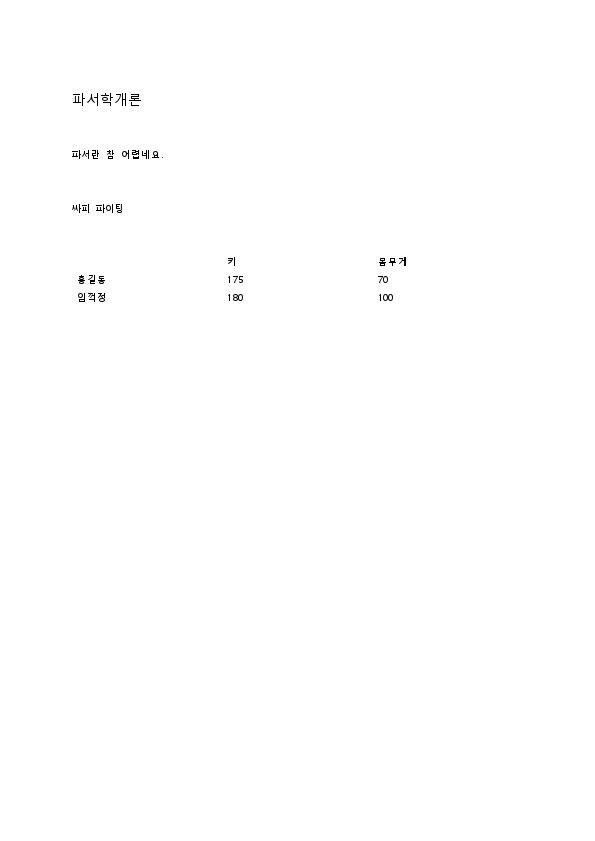

In [45]:
# 결과 확인

display(canvas)


In [46]:
# 필요하면 이미지 파일로 저장

canvas.save("page_content_render.png")
print("saved: page_content_render.png")


saved: page_content_render.png
